In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import quad
import requests, io


plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.size":        11,
})

In [21]:
url_data = ("https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease"
            "/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat")
url_cov  = ("https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease"
            "/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/"
            "Pantheon%2BSH0ES_STAT%2BSYS.cov")
 
df = pd.read_csv(url_data, sep=r'\s+')
print(f"Columns:\n{list(df.columns)}\n")
print(f"Supernovae total: {len(df)}")
 
# cosmo filter
mask   = df["zHD"] > 0.01
df_cos = df[mask].reset_index(drop=True)
print(f"Supernovae after cut SH0ES z>0.01: {len(df_cos)}")
 
# Covarance
r        = requests.get(url_cov)
lines    = r.text.split()
n_cov    = int(lines[0])
cov_flat = np.array(lines[1:], dtype=float)
cov_full = cov_flat.reshape(n_cov, n_cov)
 
idx = np.where(mask.values)[0]
cov = cov_full[np.ix_(idx, idx)]
print(f"Covariance matrix: {cov.shape}")
 
# these ones we are going to use
z      = df_cos["zHD"].values
mu_obs = df_cos["MU_SH0ES"].values
mu_err = df_cos["MU_SH0ES_ERR_DIAG"].values
 
# Survey ID ogni numero corrisponde a un survey diverso
surveys = df_cos["IDSURVEY"].values


Columns:
['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']

Supernovae total: 1701
Supernovae after cut SH0ES z>0.01: 1590
Covariance matrix: (1590, 1590)


In [22]:
print(df_cos[["zHD", "MU_SH0ES", "CEPH_DIST"]].head(20))

        zHD  MU_SH0ES  CEPH_DIST
0   0.01016   32.7794    -9.0000
1   0.01017   32.9182    -9.0000
2   0.01017   32.9674    -9.0000
3   0.01026   33.3378    -9.0000
4   0.01026   33.2253    -9.0000
5   0.01028   33.2788    33.2450
6   0.01042   33.1236    -9.0000
7   0.01044   33.0869    33.0131
8   0.01061   33.3806    33.1859
9   0.01061   33.2931    33.1859
10  0.01073   33.1081    -9.0000
11  0.01079   33.0683    33.0131
12  0.01079   33.1809    33.0131
13  0.01096   33.5709    -9.0000
14  0.01114   33.7337    -9.0000
15  0.01114   33.6369    -9.0000
16  0.01122   33.8347    -9.0000
17  0.01122   33.4336    -9.0000
18  0.01122   33.4947    -9.0000
19  0.01155   33.5833    -9.0000


In [23]:
# LCDM standard definition
 
c_light = 2.998e5  # km/s
 
def mu_lcdm(z_val, H0=70.0, Om=0.3):
    """ΛCDM flat."""
    integrand = lambda zp: 1.0 / np.sqrt(Om*(1+zp)**3 + (1-Om))
    integral, _ = quad(integrand, 0, z_val, limit=100)
    dL = (c_light / H0) * (1 + z_val) * integral
    return 5 * np.log10(dL) + 25
 
print("\nReference Model ΛCDM...")
mu_ref = np.array([mu_lcdm(zi) for zi in z])
 
# Calibration Offset!! as marginalizing
M_offset = np.mean(mu_obs - mu_ref)
mu_ref  += M_offset
residuals = mu_obs - mu_ref


Reference Model ΛCDM...


# What's in the Dataset?
Each row in the `Pantheon+SH0ES.dat` file represents a supernova and contains many columns; however, the ones that interest us are just three:

`zHD` — the supernova's redshift (measured via the redward shift of its spectral lines)
`MU_SH0ES` — the observed distance modulus, μobs
`MU_SH0ES_ERR_DIAG` — the diagonal error on μ

The distance modulus is simply the magnitude re-expressed in terms of distance:
μ = m − M = 5 log₁₀ (dL / 10 pc)


## Which Ones?
All of them, but with an important filter applied. Some supernovae in the catalog are also utilized by the SH0ES collaboration to calibrate the distance ladder using Cepheid variables; these undergo special treatment and must be excluded unless you are performing the exact same analysis. You can filter them by keeping only the rows where `zHD > 0.01`; this removes the local SNe used as calibrators, leaving approximately 1,590 cosmological supernovae.

## Quante supernova abbiamo per redshift, i.e. come è campionata la storia dell'universo. 

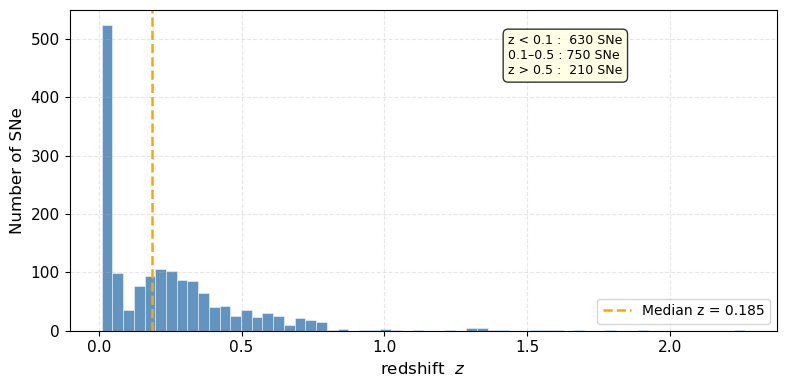

Salvato: plot1_redshift_distribution.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
 
ax.hist(z, bins=60, color="steelblue", edgecolor="white",
        linewidth=0.4, alpha=0.85)
ax.axvline(np.median(z), color="orange", lw=1.8, linestyle="--",
           label=f"Median z = {np.median(z):.3f}")
 
ax.set_xlabel("redshift  $z$", fontsize=12)
ax.set_ylabel("Number of SNe", fontsize=12)
ax.legend(fontsize=10)
 
n_low  = np.sum(z < 0.1)
n_mid  = np.sum((z >= 0.1) & (z < 0.5))
n_high = np.sum(z >= 0.5)
ax.text(0.62, 0.80,
        f"z < 0.1 :  {n_low} SNe\n"
        f"0.1–0.5 : {n_mid} SNe\n"
        f"z > 0.5 :  {n_high} SNe",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", alpha=0.8))
 
plt.tight_layout()
# plt.savefig("plot_dataset/plot1_redshift_distribution.png", dpi=150)
plt.show()
print("Salvato: plot1_redshift_distribution.png")

## Hubble diagram raw


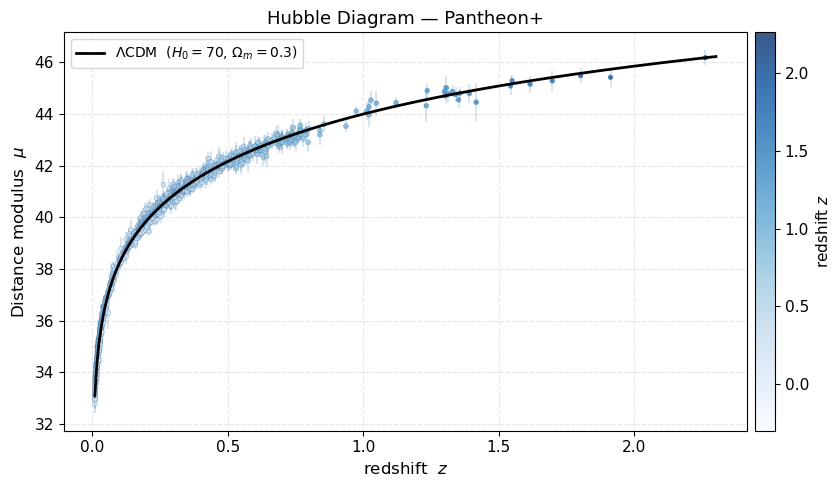

Salvato: plot2_hubble_diagram.png


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
 
ax.errorbar(z, mu_obs, yerr=mu_err,
            fmt="none",        # nessun punto, solo barre
            elinewidth=0.3,
            alpha=1,
            color="steelblue",
            zorder=2)

sc = ax.scatter(z, mu_obs, c=z, cmap="Blues",
                vmin=-0.3, s=12, alpha=0.8,
                linewidths=0.3,
                edgecolors="steelblue",
                zorder=3)
plt.colorbar(sc, ax=ax, label="redshift $z$", pad=0.01)

z_line = np.linspace(0.01, 2.3, 300)
mu_line = np.array([mu_lcdm(zi) for zi in z_line]) + M_offset
ax.plot(z_line, mu_line, "k-", lw=2, zorder=4,
        label=r"$\Lambda$CDM  ($H_0=70$, $\Omega_m=0.3$)")
 
ax.set_xlabel("redshift  $z$", fontsize=12)
ax.set_ylabel(r"Distance modulus  $\mu$", fontsize=12)
ax.set_title("Hubble Diagram — Pantheon+", fontsize=13)
ax.legend(fontsize=10)
 
plt.tight_layout()
# plt.savefig("plot2_hubble_diagram.png", dpi=150)
plt.show()
print("Salvato: plot2_hubble_diagram.png")


/Users/piter/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/piter/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


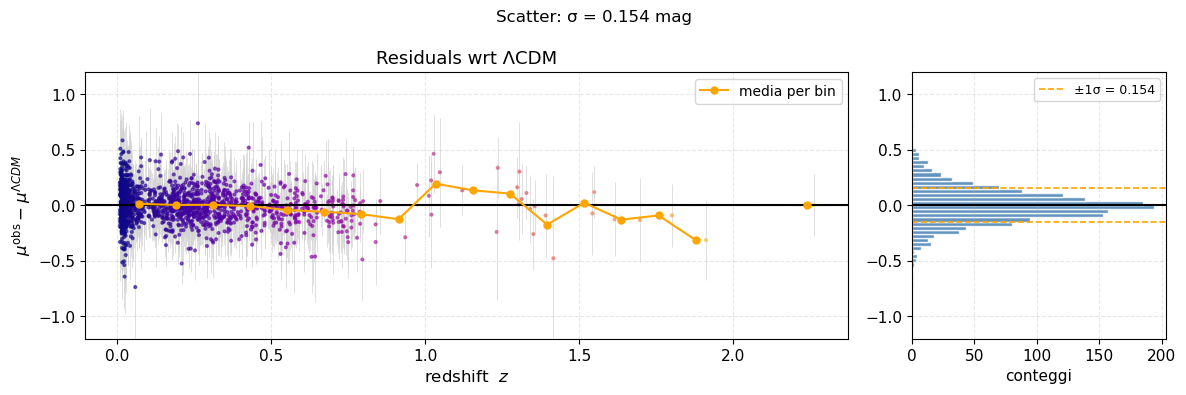

Salvato: plot3_residuals.png


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),
                                 gridspec_kw={"width_ratios": [3, 1]})
 
ax1.errorbar(z, residuals, yerr=mu_err,
             fmt="none", ecolor="lightgray", elinewidth=0.5, zorder=1)
ax1.scatter(z, residuals, c=z, cmap="plasma",
            s=4, alpha=0.6, zorder=2)
ax1.axhline(0, color="black", lw=1.5, zorder=3)
 
# Bin medi per vedere trend
z_bins   = np.linspace(0.01, 2.3, 20)
z_mid    = 0.5 * (z_bins[:-1] + z_bins[1:])
res_mean = [np.mean(residuals[(z >= z_bins[i]) & (z < z_bins[i+1])])
            for i in range(len(z_bins)-1)]
ax1.plot(z_mid, res_mean, "o-", color="orange",
         ms=5, lw=1.5, zorder=4, label="media per bin")
 
ax1.set_xlabel("redshift  $z$", fontsize=12)
ax1.set_ylabel(r"$\mu^{\rm obs} - \mu^{\Lambda CDM}$", fontsize=12)
ax1.set_title("Residuals wrt ΛCDM", fontsize=13)
ax1.set_ylim(-1.2, 1.2)
ax1.legend(fontsize=10)
 
ax2.hist(residuals, bins=40, orientation="horizontal",
         color="steelblue", edgecolor="white", lw=0.4, alpha=0.85)
ax2.axhline(0, color="black", lw=1.5)
ax2.axhline(np.std(residuals),  color="orange", lw=1.2,
            linestyle="--", label=f"±1σ = {np.std(residuals):.3f}")
ax2.axhline(-np.std(residuals), color="orange", lw=1.2, linestyle="--")
ax2.set_xlabel("conteggi", fontsize=11)
ax2.set_ylim(-1.2, 1.2)
ax2.legend(fontsize=9)
 
plt.suptitle(f"Scatter: σ = {np.std(residuals):.3f} mag",
             fontsize=12)
plt.tight_layout()
plt.savefig("plot3_residuals.png", dpi=150)
plt.show()
print("Salvato: plot3_residuals.png")

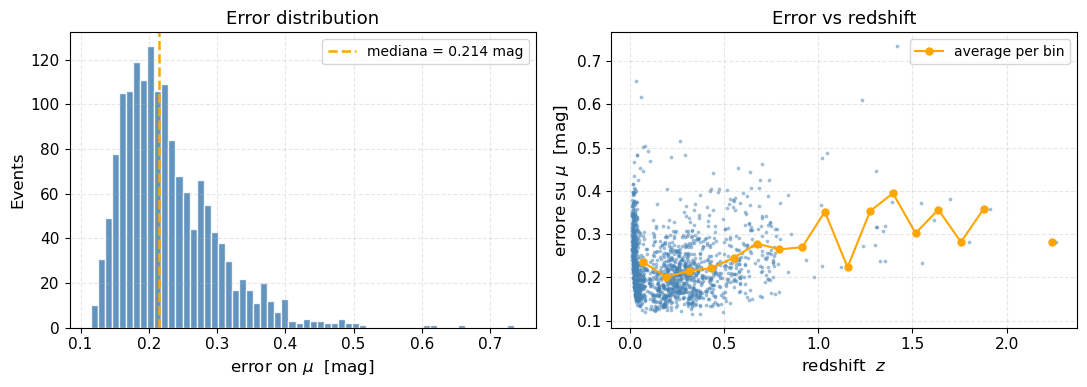

Salvato: plot4_errors.png


In [27]:
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
 
ax1.hist(mu_err, bins=60, color="steelblue",
         edgecolor="white", lw=0.4, alpha=0.85)
ax1.axvline(np.median(mu_err), color="orange", lw=1.8,
            linestyle="--", label=f"mediana = {np.median(mu_err):.3f} mag")
ax1.set_xlabel(r"error on $\mu$  [mag]", fontsize=12)
ax1.set_ylabel("Events", fontsize=12)
ax1.set_title("Error distribution", fontsize=13)
ax1.legend(fontsize=10)
 
# Error vs redshift
ax2.scatter(z, mu_err, s=3, alpha=0.4, color="steelblue")
# Trend medio
z_bins   = np.linspace(0.01, 2.3, 20)
z_mid    = 0.5 * (z_bins[:-1] + z_bins[1:])
err_mean = [np.mean(mu_err[(z >= z_bins[i]) & (z < z_bins[i+1])])
            for i in range(len(z_bins)-1)]
ax2.plot(z_mid, err_mean, "o-", color="orange", ms=5, lw=1.5,
         label="average per bin")
ax2.set_xlabel("redshift  $z$", fontsize=12)
ax2.set_ylabel(r"errore su $\mu$  [mag]", fontsize=12)
ax2.set_title("Error vs redshift", fontsize=13)
ax2.legend(fontsize=10)
 
plt.tight_layout()
# plt.savefig("plot4_errors.png", dpi=150)
plt.show()
print("Salvato: plot4_errors.png")

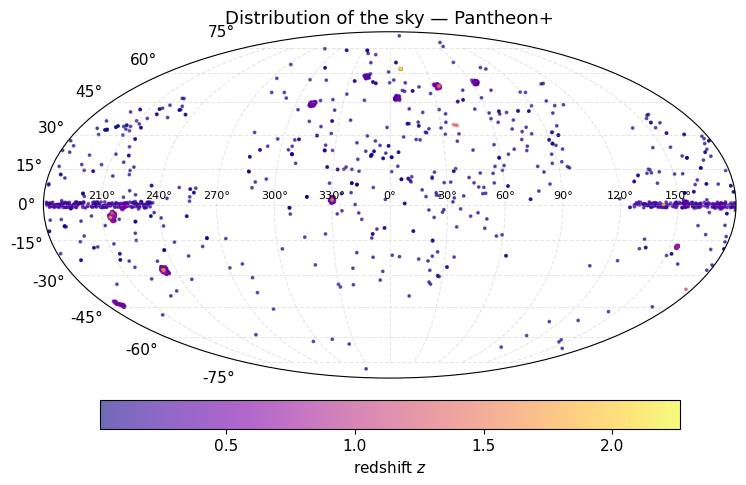

Salvato: plot5_skymap.png


In [28]:
if "RA" in df_cos.columns and "DEC" in df_cos.columns:
    ra  = df_cos["RA"].values
    dec = df_cos["DEC"].values
 

    ra_rad  = np.deg2rad(ra - 180)
    dec_rad = np.deg2rad(dec)
 
    fig = plt.figure(figsize=(10, 5))
    ax  = fig.add_subplot(111, projection="mollweide")
 
    sc = ax.scatter(ra_rad, dec_rad, c=z, cmap="plasma",
                    s=3, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="redshift $z$",
                 orientation="horizontal", pad=0.05, shrink=0.6)
 
    ax.set_title("Distribution of the sky — Pantheon+", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels(["210°","240°","270°","300°","330°",
                         "0°","30°","60°","90°","120°","150°"],
                        fontsize=8)
 
    plt.tight_layout()
    # plt.savefig("plot5_skymap.png", dpi=150)
    plt.show()
    print("Salvato: plot5_skymap.png")
else:
    print("Colonne RA/DEC non trovate, salto la mappa del cielo.")

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/var/folders/_3/d51kyvks4z383nhtd29lybxh0000gn/T/ipykernel_67938/324846071.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Error on $\mu$ [mag]", fontsize=12)


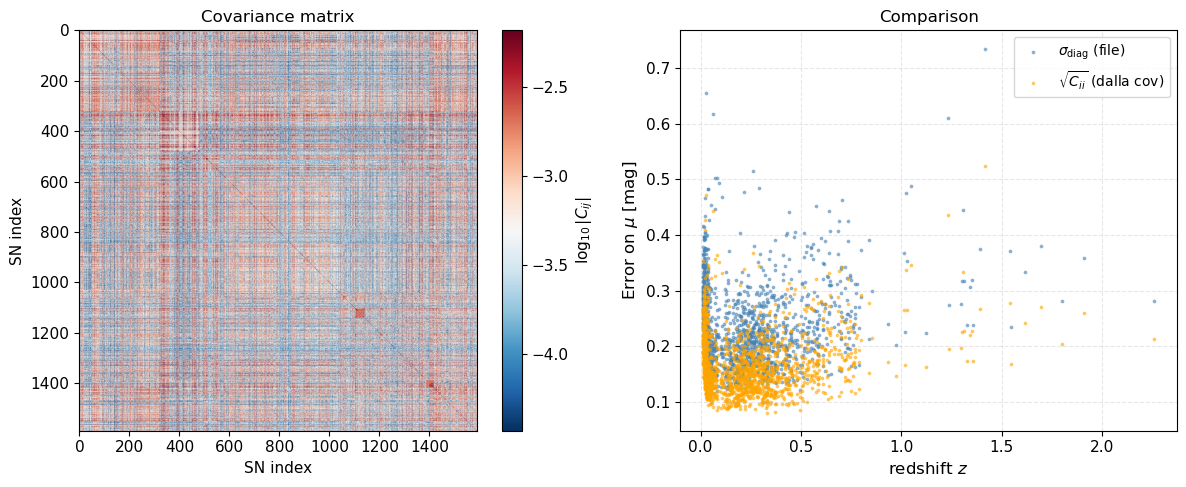

Salvato: plot6_covariance.png


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
cov_diag_vals = np.diag(cov)
 
sort_idx   = np.argsort(surveys)
cov_sorted = cov[np.ix_(sort_idx, sort_idx)]
 
im = ax1.imshow(
    np.log10(np.abs(cov_sorted) + 1e-10),
    cmap="RdBu_r", aspect="auto",
    vmin=np.percentile(np.log10(np.abs(cov)+1e-10), 5),
    vmax=np.percentile(np.log10(np.abs(cov)+1e-10), 99)
)
plt.colorbar(im, ax=ax1, label=r"$\log_{10}|C_{ij}|$")
ax1.set_title("Covariance matrix", fontsize=12)
ax1.set_xlabel("SN index", fontsize=11)
ax1.set_ylabel("SN index", fontsize=11)
 
# Confronto: errore diagonale vs sqrt(C_ii)
ax2.scatter(z, mu_err, s=3, alpha=0.5, label=r"$\sigma_{\rm diag}$ (file)",
            color="steelblue")
ax2.scatter(z, np.sqrt(cov_diag_vals), s=3, alpha=0.5,
            label=r"$\sqrt{C_{ii}}$ (dalla cov)", color="orange")
ax2.set_xlabel("redshift $z$", fontsize=12)
ax2.set_ylabel("Error on $\mu$ [mag]", fontsize=12)
ax2.set_title("Comparison", fontsize=12)
ax2.legend(fontsize=10)
 
plt.tight_layout()
# plt.savefig("plot6_covariance.png", dpi=150)
plt.show()
print("Salvato: plot6_covariance.png")
 

In [30]:
print(f"Supernovae in the:     {len(df)}")
print(f"Supernovae after cut z>0.01:     {len(df_cos)}")
print(f"Range redshift:                    {z.min():.4f} – {z.max():.4f}")
print(f"Median redshift:                  {np.median(z):.4f}")
print(f"Range modulo di distanza:          {mu_obs.min():.2f} – {mu_obs.max():.2f} mag")
print(f"Errore medio su mu:                {mu_err.mean():.4f} mag")
print(f"Errore mediano su mu:              {np.median(mu_err):.4f} mag")
print(f"Scatter residui (sigma):           {np.std(residuals):.4f} mag")
print(f"Survey diversi presenti:           {df_cos['IDSURVEY'].nunique()}")
print(f"Correlazione media off-diag (cov): {np.mean(np.abs(cov[~np.eye(len(cov), dtype=bool)])):.6f}")

Supernovae in the:     1701
Supernovae after cut z>0.01:     1590
Range redshift:                    0.0102 – 2.2614
Median redshift:                  0.1846
Range modulo di distanza:          32.78 – 46.18 mag
Errore medio su mu:                0.2288 mag
Errore mediano su mu:              0.2143 mag
Scatter residui (sigma):           0.1541 mag
Survey diversi presenti:           20
Correlazione media off-diag (cov): 0.000892


In [31]:
mask_local = df["zHD"] <= 0.01
print(f"SNe con z < 0.01: {mask_local.sum()}")
print(df[mask_local][["zHD", "MU_SH0ES", "CEPH_DIST"]].head(20))

SNe con z < 0.01: 111
        zHD  MU_SH0ES  CEPH_DIST
0   0.00122   28.9987    29.1770
1   0.00122   29.0559    29.1770
2   0.00256   30.7233    30.8433
3   0.00256   30.7449    30.8433
4   0.00299   30.7757    -9.0000
5   0.00317   30.7946    30.8338
6   0.00331   30.4604    30.5454
7   0.00331   30.5528    30.5454
8   0.00331   30.4013    30.5454
9   0.00331   30.5107    30.5454
10  0.00333   31.5011    31.2859
11  0.00349   31.7933    31.6336
12  0.00349   31.4967    31.7216
13  0.00359   31.6969    31.8115
14  0.00384   30.9999    31.2859
15  0.00407   31.3933    31.4903
16  0.00407   31.3779    31.4903
17  0.00432   31.4990    31.6272
18  0.00432   31.5611    31.6272
19  0.00465   31.9309    31.9348


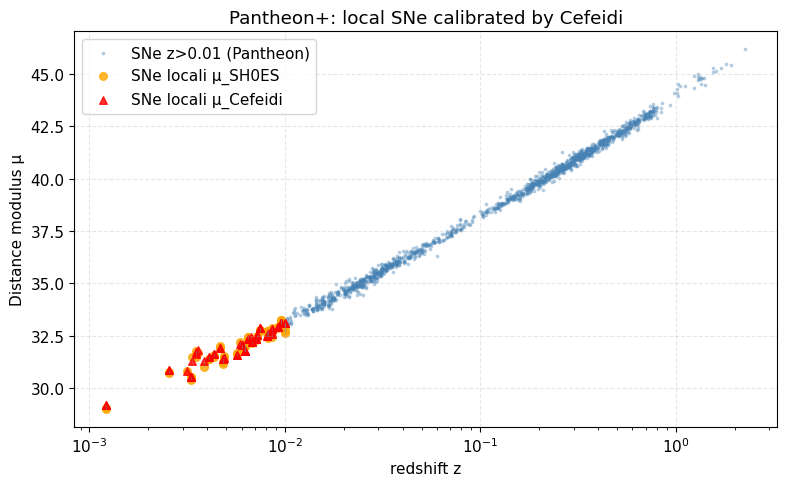

In [32]:
df_all = pd.read_csv("Pantheon+SH0ES.dat", sep=r'\s+')
mask_local = df_all["zHD"] <= 0.01
mask_ceph = df_all["CEPH_DIST"] > 0 # esclude -9.0
df_local = df_all[mask_local & mask_ceph]

fig, ax = plt.subplots(figsize=(8, 5))

df_far = df_all[df_all["zHD"] > 0.01]
ax.scatter(df_far["zHD"], df_far["MU_SH0ES"],
           s=3, alpha=0.3, color="steelblue", label="SNe z>0.01 (Pantheon)")

# SNe local: MU_SH0ES vs CEPH_DIST
ax.scatter(df_local["zHD"], df_local["MU_SH0ES"],
           s=30, alpha=0.8, color="orange", label="SNe locali μ_SH0ES")
ax.scatter(df_local["zHD"], df_local["CEPH_DIST"],
           s=30, alpha=0.8, color="red", marker="^", label="SNe locali μ_Cefeidi")

# linee che collegano μ_SH0ES e μ_Cefeidi per ogni SN locale
for _, row in df_local.iterrows():
    ax.plot([row["zHD"], row["zHD"]],
            [row["MU_SH0ES"], row["CEPH_DIST"]],
            color="gray", lw=0.5, alpha=0.5)

ax.set_xlabel("redshift z")
ax.set_ylabel("Distance modulus μ")
ax.set_title("Pantheon+: local SNe calibrated by Cefeidi")
ax.legend()
ax.set_xscale("log")
plt.tight_layout()
plt.show()

Le SNe locali (arancione) sono i punti μ_SH0ES a z < 0.01. I triangoli rossi sono la misura indipendente delle Cefeidi per la stessa SN. Le linee grigie collegano le due misure — la loro differenza è esattamente l'offset di calibrazione assoluta che ancora H0.

# BAO

In [33]:
BAO_DATA = [
    # z      DM/rd   sDM    DH/rd   sDH    rho
    (0.295,  7.93,   0.15,  20.08,  0.60,  -0.39),  # BGS
    (0.510,  13.62,  0.25,  20.98,  0.61,  -0.44),  # LRG1
    (0.706,  16.85,  0.32,  20.08,  0.60,  -0.35),  # LRG2
    (0.930,  21.71,  0.28,  17.88,  0.35,  -0.38),  # LRG3+ELG1
    (1.317,  27.79,  0.69,  13.82,  0.42,  -0.47),  # ELG2
    (1.491,  30.21,  0.79,  12.90,  0.40,  -0.43),  # QSO
    (2.330,  39.71,  0.94,   8.52,  0.17,  -0.45),  # Lya
]
 
labels = ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", "Lyα"]
 
z_arr   = np.array([d[0] for d in BAO_DATA])
DM_rd   = np.array([d[1] for d in BAO_DATA])
sDM     = np.array([d[2] for d in BAO_DATA])
DH_rd   = np.array([d[3] for d in BAO_DATA])
sDH     = np.array([d[4] for d in BAO_DATA])
rho     = np.array([d[5] for d in BAO_DATA])


"""
ΛCDM
"""

c_light = 2.998e5   # km/s
H0      = 67.4      # km/s/Mpc  (Planck 2018)
Om      = 0.315
rd      = 147.09    # Mpc  (sound horizon, Planck 2018)
 
def E(z, Om=Om):
    return np.sqrt(Om*(1+z)**3 + (1-Om))
 
def DM_model(z):
    """Commoving distance units of rd"""
    integral, _ = quad(lambda zp: 1.0/E(zp), 0, z, limit=100)
    return (c_light / H0) * integral / rd
 
def DH_model(z):
    """c/H(z) in rd units."""
    return (c_light / (H0 * E(z))) / rd
 
z_line  = np.linspace(0.1, 2.6, 300)
DM_line = np.array([DM_model(zi) for zi in z_line])
DH_line = np.array([DH_model(zi) for zi in z_line])
 

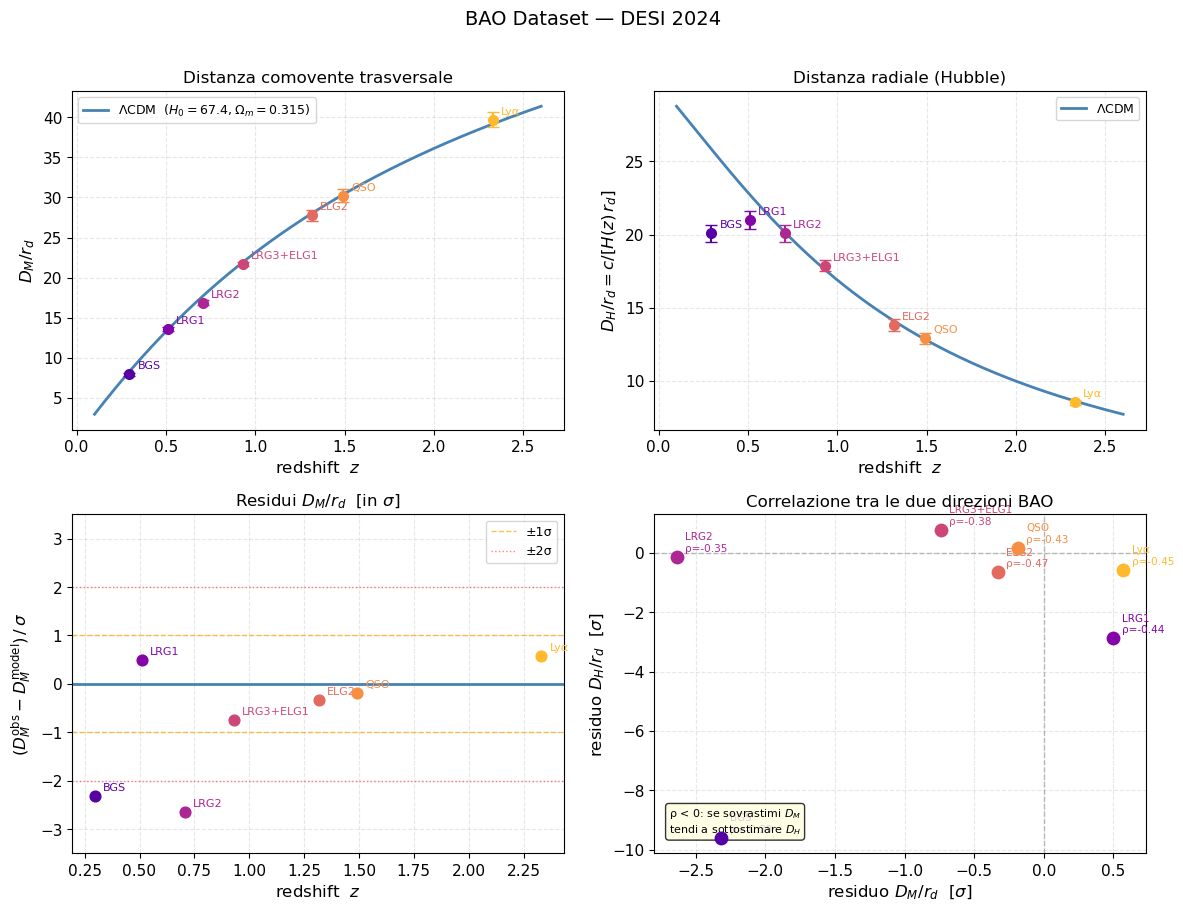

Salvato: bao_exploration.png


In [34]:
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(z_arr)))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("BAO Dataset — DESI 2024", fontsize=14, y=1.01)
 
# ── Panel 1: DM/rd vs z ──────────────────────────────
ax = axes[0, 0]
ax.plot(z_line, DM_line, "-", color="steelblue", lw=2,
        label=r"$\Lambda$CDM  ($H_0=67.4$, $\Omega_m=0.315$)")
for i, (z, dm, sdm, lbl) in enumerate(zip(z_arr, DM_rd, sDM, labels)):
    ax.errorbar(z, dm, yerr=sdm, fmt="o", color=colors[i],
                ms=7, capsize=4, zorder=4)
    ax.annotate(lbl, (z, dm), textcoords="offset points",
                xytext=(6, 4), fontsize=8, color=colors[i])
 
ax.set_xlabel("redshift  $z$", fontsize=12)
ax.set_ylabel(r"$D_M / r_d$", fontsize=12)
ax.set_title("Distanza comovente trasversale", fontsize=12)
ax.legend(fontsize=9)
 
# ── Panel 2: DH/rd vs z ──────────────────────────────
ax = axes[0, 1]
ax.plot(z_line, DH_line, "-", color="steelblue", lw=2,
        label=r"$\Lambda$CDM")
for i, (z, dh, sdh, lbl) in enumerate(zip(z_arr, DH_rd, sDH, labels)):
    ax.errorbar(z, dh, yerr=sdh, fmt="o", color=colors[i],
                ms=7, capsize=4, zorder=4)
    ax.annotate(lbl, (z, dh), textcoords="offset points",
                xytext=(6, 4), fontsize=8, color=colors[i])
 
ax.set_xlabel("redshift  $z$", fontsize=12)
ax.set_ylabel(r"$D_H / r_d = c / [H(z)\, r_d]$", fontsize=12)
ax.set_title("Distanza radiale (Hubble)", fontsize=12)
ax.legend(fontsize=9)
 
# ── Panel 3: Residui DM/rd ───────────────────────────
ax = axes[1, 0]
DM_pred = np.array([DM_model(zi) for zi in z_arr])
res_DM  = (DM_rd - DM_pred) / sDM 
 
ax.axhline(0,  color="steelblue", lw=2)
ax.axhline( 1, color="orange", lw=1, linestyle="--", alpha=0.7)
ax.axhline(-1, color="orange", lw=1, linestyle="--", alpha=0.7, label="±1σ")
ax.axhline( 2, color="red",    lw=1, linestyle=":",  alpha=0.5)
ax.axhline(-2, color="red",    lw=1, linestyle=":",  alpha=0.5, label="±2σ")
 
for i, (z, res, lbl) in enumerate(zip(z_arr, res_DM, labels)):
    ax.scatter(z, res, color=colors[i], s=60, zorder=4)
    ax.annotate(lbl, (z, res), textcoords="offset points",
                xytext=(6, 4), fontsize=8, color=colors[i])
 
ax.set_xlabel("redshift  $z$", fontsize=12)
ax.set_ylabel(r"$(D_M^{\rm obs} - D_M^{\rm model})\,/\,\sigma$", fontsize=12)
ax.set_title(r"Residui $D_M/r_d$  [in $\sigma$]", fontsize=12)
ax.set_ylim(-3.5, 3.5)
ax.legend(fontsize=9)
 
ax = axes[1, 1]
 
DH_pred = np.array([DH_model(zi) for zi in z_arr])
res_DH  = (DH_rd - DH_pred) / sDH
 
for i, (rdm, rdh, lbl, r) in enumerate(
        zip((DM_rd - DM_pred)/sDM, (DH_rd - DH_pred)/sDH, labels, rho)):
    ax.scatter(rdm, rdh, color=colors[i], s=80, zorder=4)
    ax.annotate(f"{lbl}\nρ={r:.2f}", (rdm, rdh),
                textcoords="offset points",
                xytext=(6, 4), fontsize=7.5, color=colors[i])
 
ax.axhline(0, color="gray", lw=1, linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", lw=1, linestyle="--", alpha=0.5)
ax.set_xlabel(r"residuo $D_M/r_d$  [$\sigma$]", fontsize=12)
ax.set_ylabel(r"residuo $D_H/r_d$  [$\sigma$]", fontsize=12)
ax.set_title("Correlazione tra le due direzioni BAO", fontsize=12)
 
ax.text(0.03, 0.06,
        "ρ < 0: se sovrastimi $D_M$\ntendi a sottostimare $D_H$",
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))
 
plt.tight_layout()
# plt.savefig("bao_exploration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: bao_exploration.png")
 

In alto a sinistra — DM/rdD_M/r_d
DM​/rd​ vs zz
z: la distanza comovente trasversale cresce con il redshift. I punti devono stare sulla curva ΛCDM. Nota che DMD_M
DM​ cresce monotonicamente — più lontano = più grande.

In alto a destra — DH/rdD_H/r_d
DH​/rd​ vs zz
z: questa è c/H(z)c/H(z)
c/H(z) normalizzata. Decresce con zz
z perché nell'universo passato H(z)H(z)
H(z) era più grande (espansione più veloce dominata dalla materia). È la misura più diretta di come cambia il tasso di espansione nel tempo.

In basso a sinistra — residui in σ\sigma
σ: il plot più importante per la validazione. Se tutti i punti stanno entro ±2σ\pm 2\sigma
±2σ il modello è compatibile con i dati. Se qualche punto è oltre 2σ2\sigma
2σ in modo sistematico è un segnale che il modello non è perfetto — o che c'è nuova fisica.

In basso a destra — correlazione DMD_M
DM​ vs DHD_H
DH​: tutti i valori ρ\rho
ρ sono negativi (circa −0.4-0.4
−0.4). Questo è fisicamente sensato — se misuri il picco BAO spostato verso angoli più grandi (sovrastimi DMD_M
DM​), tendi contemporaneamente a misurarlo spostato verso Δz\Delta z
Δz più piccoli (sottostimi DHD_H
DH​). Le due misure non sono indipendenti, e questo va nella likelihood.